In [2]:
import pandas as pd

df = pd.read_csv("hour.csv")

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (17379, 17)

Column names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

First 5 rows:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df[['temp', 'hum', 'windspeed', 'cnt']].describe()

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Basic statistics:


,temp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.627229,0.190098,189.463088
std,0.192556,0.192930,0.122340,181.387599
min,0.020000,0.000000,0.000000,1.000000
25%,0.340000,0.480000,0.104500,40.000000
50%,0.500000,0.630000,0.194000,142.000000
75%,0.660000,0.780000,0.253700,281.000000
max,1.000000,1.000000,0.850700,977.000000


Matplotlib is building the font cache; this may take a moment.


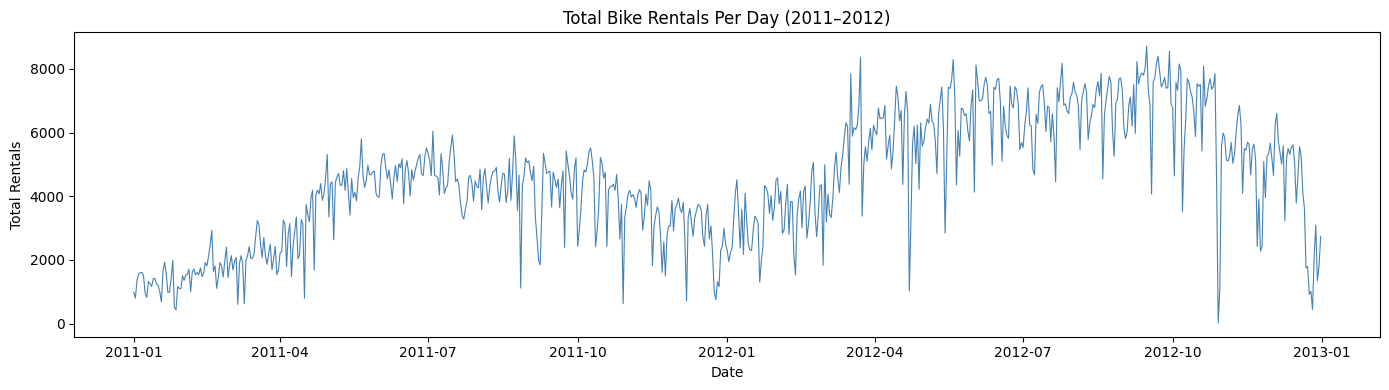

In [4]:
import matplotlib.pyplot as plt

df['dteday'] = pd.to_datetime(df['dteday'])

daily = df.groupby('dteday')['cnt'].sum()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
plt.title('Total Bike Rentals Per Day (2011–2012)')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.tight_layout()
plt.show()

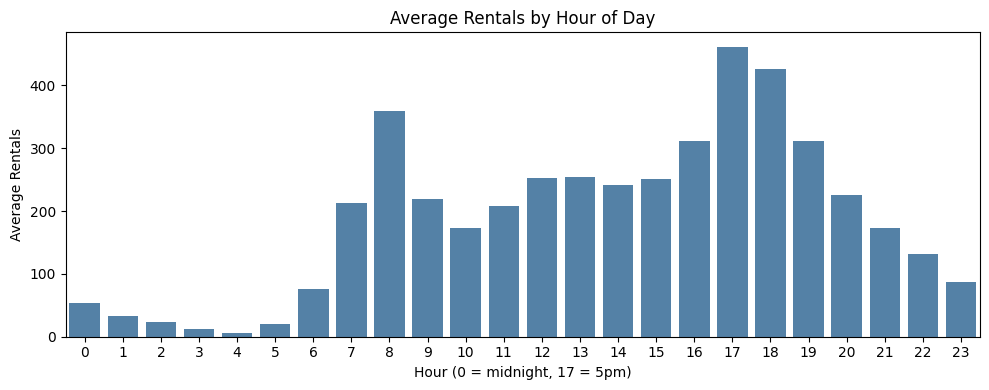

In [5]:
import seaborn as sns

hourly = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10, 4))
sns.barplot(x=hourly.index, y=hourly.values, color='steelblue')
plt.title('Average Rentals by Hour of Day')
plt.xlabel('Hour (0 = midnight, 17 = 5pm)')
plt.ylabel('Average Rentals')
plt.tight_layout()
plt.show()

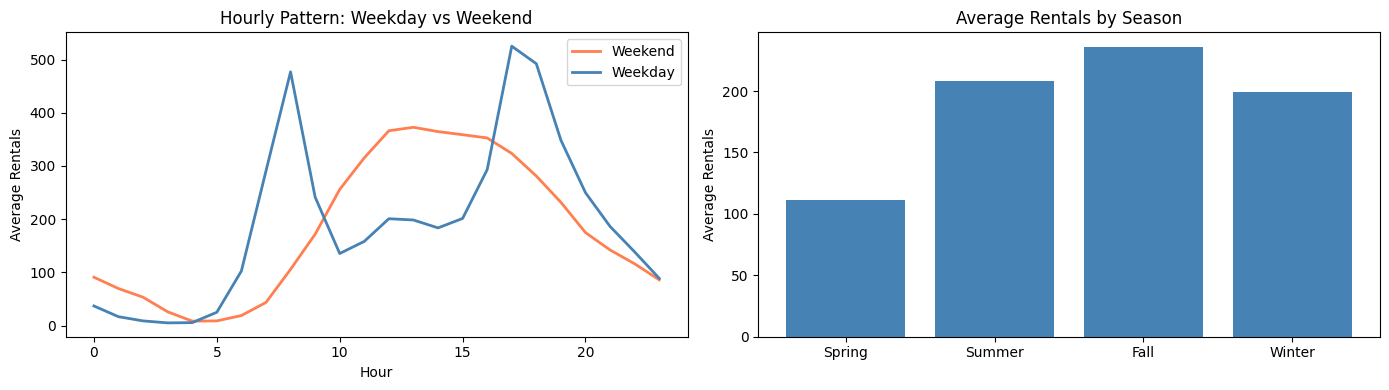

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Weekdays vs Weekends by hour
for day_type, label, color in [(0, 'Weekend', 'coral'), (1, 'Weekday', 'steelblue')]:
    subset = df[df['workingday'] == day_type]
    hourly = subset.groupby('hr')['cnt'].mean()
    axes[0].plot(hourly.index, hourly.values, label=label, color=color, linewidth=2)

axes[0].set_title('Hourly Pattern: Weekday vs Weekend')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Rentals')
axes[0].legend()

# By season
seasonal = df.groupby('season')['cnt'].mean()
axes[1].bar(['Spring','Summer','Fall','Winter'], seasonal.values, color='steelblue')
axes[1].set_title('Average Rentals by Season')
axes[1].set_ylabel('Average Rentals')

plt.tight_layout()
plt.show()

In [7]:
# Convert date column to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# --- Time-based features ---
df['hour'] = df['hr']
df['month'] = df['dteday'].dt.month
df['day_of_week'] = df['dteday'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['quarter'] = df['dteday'].dt.quarter

# --- Lag features (giving the model "memory") ---
df = df.sort_values('dteday').reset_index(drop=True)
df['lag_1hr'] = df['cnt'].shift(1)    # rentals 1 hour ago
df['lag_24hr'] = df['cnt'].shift(24)  # rentals same hour yesterday
df['lag_168hr'] = df['cnt'].shift(168) # rentals same hour last week

# --- Rolling averages (recent momentum) ---
df['rolling_3hr'] = df['cnt'].shift(1).rolling(3).mean()
df['rolling_24hr'] = df['cnt'].shift(1).rolling(24).mean()

# Drop rows where lag features are NaN (first 168 rows)
df = df.dropna().reset_index(drop=True)

print("New shape:", df.shape)
print("\nNew columns added:")
print(['hour','month','day_of_week','is_weekend','is_rush_hour',
       'quarter','lag_1hr','lag_24hr','lag_168hr','rolling_3hr','rolling_24hr'])
print("\nSample of new features:")
df[['dteday','hour','is_weekend','is_rush_hour','lag_1hr','lag_24hr','rolling_3hr','cnt']].head(8)

New shape: (17211, 28)

New columns added:
['hour', 'month', 'day_of_week', 'is_weekend', 'is_rush_hour', 'quarter', 'lag_1hr', 'lag_24hr', 'lag_168hr', 'rolling_3hr', 'rolling_24hr']

Sample of new features:


,dteday,hour,is_weekend,is_rush_hour,lag_1hr,lag_24hr,rolling_3hr,cnt
0,2011-01-08,17,1,1,55.0,39.0,37.666667,69
1,2011-01-08,16,1,0,69.0,36.0,51.333333,76
2,2011-01-08,15,1,0,76.0,15.0,66.666667,74
3,2011-01-08,13,1,0,74.0,95.0,73.000000,102
4,2011-01-08,12,1,0,102.0,73.0,84.000000,98
5,2011-01-08,0,1,0,98.0,84.0,91.333333,25
6,2011-01-08,11,1,0,25.0,67.0,75.000000,62
7,2011-01-08,1,1,0,62.0,7.0,61.666667,16


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features we'll use
features = ['hour', 'month', 'day_of_week', 'is_weekend', 'is_rush_hour',
            'quarter', 'workingday', 'holiday', 'season', 'weathersit',
            'temp', 'hum', 'windspeed', 'lag_1hr', 'lag_24hr', 
            'lag_168hr', 'rolling_3hr', 'rolling_24hr']

X = df[features]
y = df['cnt']

# Time-aware split — last 20% is test set
split = int(len(df) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training on {len(X_train)} hours")
print(f"Testing on {len(X_test)} hours")

# Train the model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("\nModel trained!")

Training on 13768 hours
Testing on 3443 hours

Model trained!


        OUR MODEL        BASELINE
MAE:    42.2          146.5
RMSE:   66.1         209.7


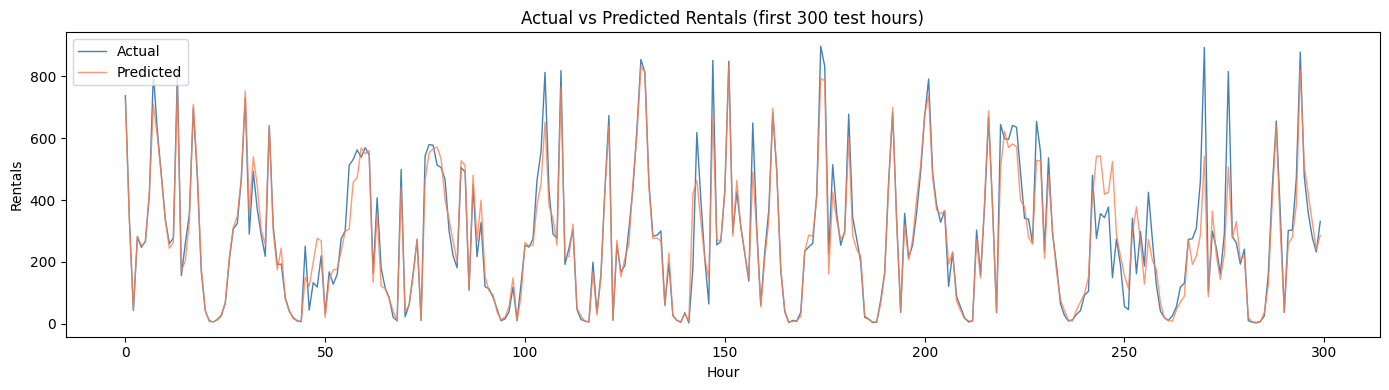

In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Baseline: just predict the previous hour's rentals
baseline_pred = X_test['lag_1hr']

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("=" * 40)
print("        OUR MODEL        BASELINE")
print("=" * 40)
print(f"MAE:    {mae:.1f}          {baseline_mae:.1f}")
print(f"RMSE:   {rmse:.1f}         {baseline_rmse:.1f}")
print("=" * 40)

# Plot predictions vs actual
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:300], label='Actual', color='steelblue', linewidth=1)
plt.plot(y_pred[:300], label='Predicted', color='coral', linewidth=1, alpha=0.8)
plt.title('Actual vs Predicted Rentals (first 300 test hours)')
plt.xlabel('Hour')
plt.ylabel('Rentals')
plt.legend()
plt.tight_layout()
plt.show()

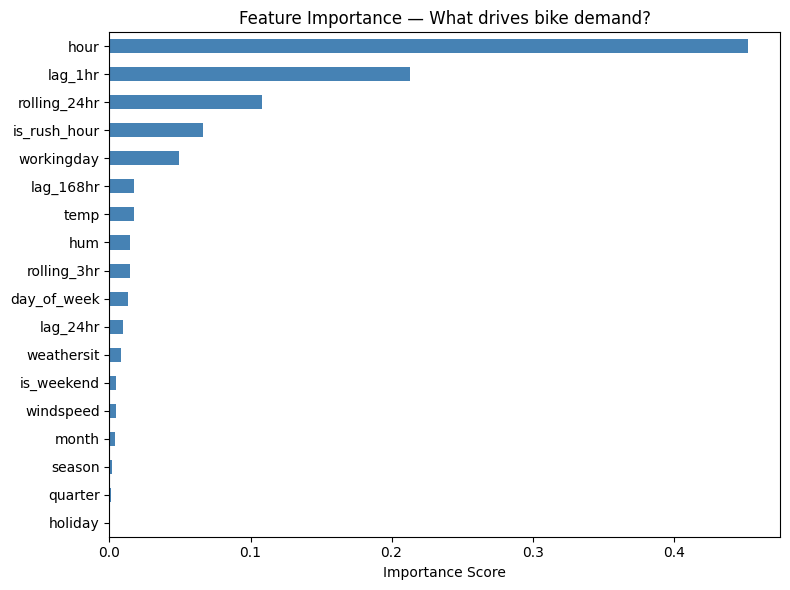

In [10]:
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — What drives bike demand?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()